In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
DATA_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/crops_npk/crops_npk.csv"

print("Dataset exists:", os.path.exists(DATA_PATH))

Dataset exists: True


In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (20000, 10)


In [5]:
print("Dataset Columns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Columns:
['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall', 'Crop', 'Soil_Type', 'Variety']

First 5 Rows:


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet


In [6]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     20000 non-null  float64
 1   Phosphorus   20000 non-null  float64
 2   Potassium    20000 non-null  float64
 3   Temperature  20000 non-null  float64
 4   Humidity     20000 non-null  float64
 5   pH_Value     20000 non-null  float64
 6   Rainfall     20000 non-null  float64
 7   Crop         20000 non-null  object 
 8   Soil_Type    20000 non-null  object 
 9   Variety      20000 non-null  object 
dtypes: float64(7), object(3)
memory usage: 1.5+ MB


In [7]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

MISSING VALUES
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
Soil_Type      0
Variety        0
dtype: int64

Total missing values: 0


In [8]:
print("=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

DUPLICATE CHECK
Duplicate rows: 0


In [9]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe())

DESCRIPTIVE STATISTICS


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,77.216965,47.482070,55.162956,27.420717,64.897753,6.496126,211.124002
std,41.857663,24.587506,25.969091,10.010144,20.200687,1.155750,109.724973
min,5.006013,5.000483,10.000672,10.003760,30.002297,4.500082,20.018991
25%,40.459715,26.225044,32.641905,18.880888,47.462026,5.497988,117.208556
50%,77.573159,47.469579,55.248133,27.366450,64.776613,6.493812,211.263577
75%,113.055595,68.625556,77.690183,35.997484,82.310482,7.501771,305.668849
max,149.998785,89.999086,99.996480,44.997407,99.992346,8.499914,399.974915


In [10]:
print("=" * 60)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 60)

categorical_cols = ['Crop', 'Soil_Type', 'Variety']

for col in categorical_cols:
    print(f"\n{col}")
    print("-" * 40)
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(20))

CATEGORICAL VARIABLES ANALYSIS

Crop
----------------------------------------
Unique values: 6
Crop
Wheat        3390
Potato       3362
Maize        3352
Tomato       3344
Sugarcane    3284
Rice         3268
Name: count, dtype: int64

Soil_Type
----------------------------------------
Unique values: 6
Soil_Type
Silt      3422
Clay      3401
Saline    3365
Sandy     3312
Peaty     3291
Loamy     3209
Name: count, dtype: int64

Variety
----------------------------------------
Unique values: 18
Variety
Durum         1162
Russet        1148
Sweet         1141
Roma          1138
Hard Red      1135
Beefsteak     1133
Co 86032      1122
Red           1119
Flint         1108
Arborio       1104
Basmati       1104
Dent          1103
Yukon Gold    1095
Soft Red      1093
Co 99004      1089
Co 0238       1073
Cherry        1073
Jasmine       1060
Name: count, dtype: int64


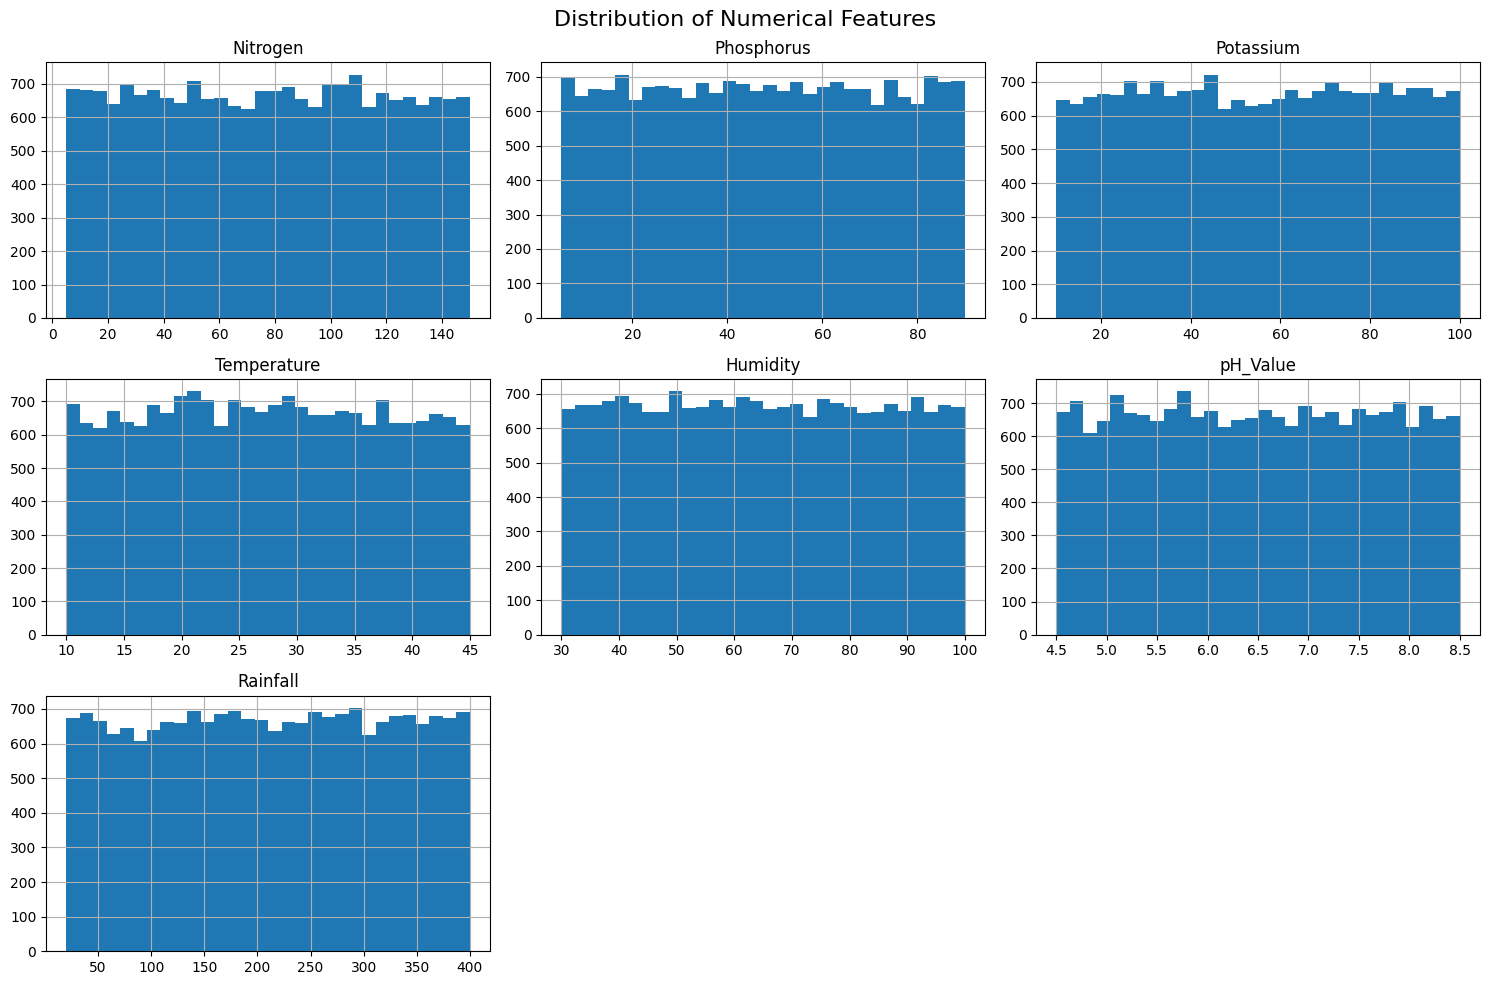

In [11]:
numerical_cols = [
    'Nitrogen',
    'Phosphorus',
    'Potassium',
    'Temperature',
    'Humidity',
    'pH_Value',
    'Rainfall'
]

df[numerical_cols].hist(figsize=(15, 10), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

correlation_matrix = df[numerical_cols].corr()

display(correlation_matrix.round(3))

CORRELATION ANALYSIS


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
Nitrogen,1.000,0.001,0.004,0.004,0.002,0.000,0.002
Phosphorus,0.001,1.000,0.014,0.005,0.007,0.006,0.000
Potassium,0.004,0.014,1.000,0.005,0.002,-0.001,0.009
Temperature,0.004,0.005,0.005,1.000,0.005,0.008,0.003
Humidity,0.002,0.007,0.002,0.005,1.000,-0.012,0.003
pH_Value,0.000,0.006,-0.001,0.008,-0.012,1.000,0.004
Rainfall,0.002,0.000,0.009,0.003,0.003,0.004,1.000


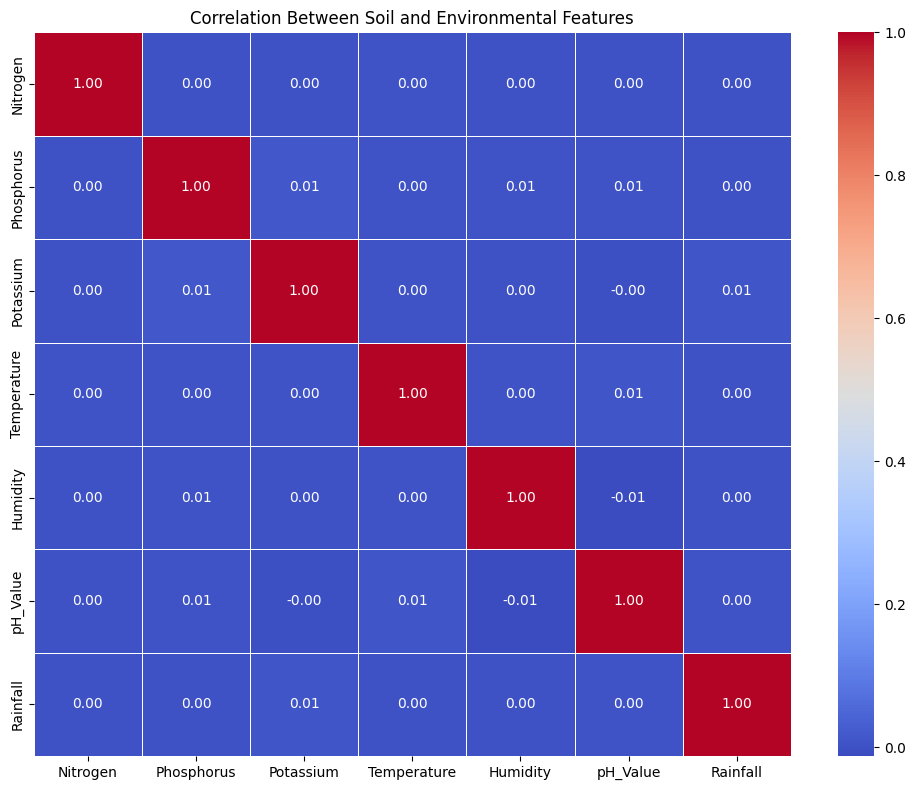

In [13]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Soil and Environmental Features")
plt.tight_layout()
plt.show()

The correlation analysis revealed no strong linear relationships among the soil nutrient and environmental variables. Most correlation coefficients were close to zero, indicating that each feature provides relatively independent information for crop recommendation and predictive modeling.

In [14]:
print("=" * 60)
print("AVERAGE SOIL CONDITIONS BY CROP")
print("=" * 60)

crop_analysis = df.groupby('Crop')[
    ['Nitrogen', 'Phosphorus', 'Potassium', 'pH_Value']
].mean().round(2)

display(crop_analysis)

AVERAGE SOIL CONDITIONS BY CROP


,Nitrogen,Phosphorus,Potassium,pH_Value
Crop,,,,
Maize,78.53,47.01,54.85,6.51
Potato,75.49,47.62,54.80,6.50
Rice,76.10,47.78,55.48,6.51
Sugarcane,77.96,46.91,55.29,6.52
Tomato,76.45,47.10,55.01,6.47
Wheat,78.75,48.46,55.56,6.46


<Figure size 1200x600 with 0 Axes>

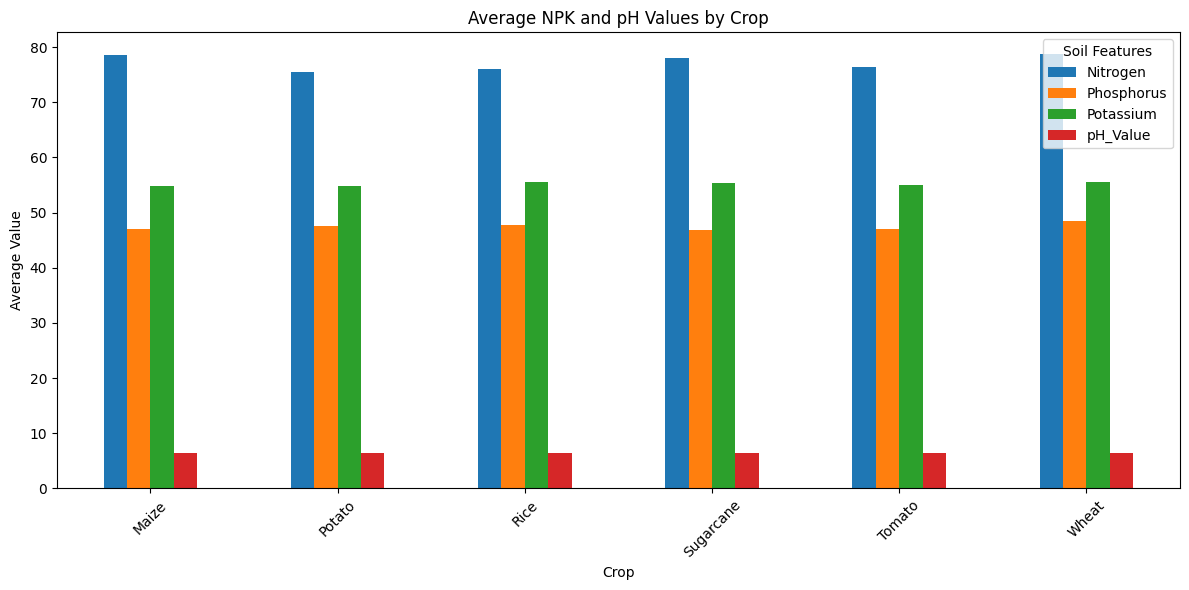

In [15]:
plt.figure(figsize=(12, 6))

crop_analysis.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Average NPK and pH Values by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Soil Features")
plt.tight_layout()
plt.show()

In [16]:
print("=" * 60)
print("CROP DISTRIBUTION BY SOIL TYPE")
print("=" * 60)

crop_soil = pd.crosstab(
    df['Crop'],
    df['Soil_Type']
)

display(crop_soil)

CROP DISTRIBUTION BY SOIL TYPE


Soil_Type,Clay,Loamy,Peaty,Saline,Sandy,Silt
Crop,,,,,,
Maize,554,534,512,558,594,600
Potato,580,529,549,554,527,623
Rice,558,498,538,566,545,563
Sugarcane,585,529,545,590,500,535
Tomato,561,574,578,555,536,540
Wheat,563,545,569,542,610,561


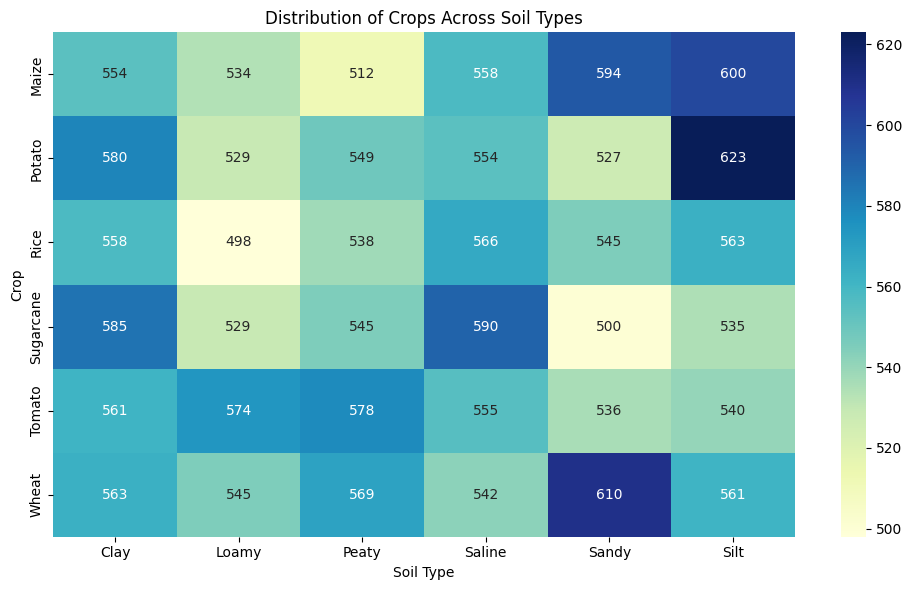

In [17]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_soil,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Distribution of Crops Across Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [18]:
print("=" * 70)
print("EDA SUMMARY AND KEY FINDINGS")
print("=" * 70)

print("""
1. The dataset contains 20,000 records and 10 features.

2. There are no missing values in the dataset.

3. No duplicate records were identified.

4. The dataset contains:
   - 6 Crop categories
   - 6 Soil Type categories
   - 18 Crop Variety categories

5. The crop and soil type categories are relatively balanced.

6. Numerical variables show broad distributions across their respective ranges.

7. Correlation analysis revealed very weak linear relationships
   between the numerical soil and environmental features.

8. Average NPK and pH values vary slightly across crop categories.

9. Crops are distributed across all soil types, indicating that
   crop recommendations should consider multiple soil and environmental
   variables together rather than relying on soil type alone.

CONCLUSION:
The dataset is clean, balanced, and suitable for further preprocessing
and machine learning model development for intelligent crop advisory.
""")

EDA SUMMARY AND KEY FINDINGS

1. The dataset contains 20,000 records and 10 features.

2. There are no missing values in the dataset.

3. No duplicate records were identified.

4. The dataset contains:
   - 6 Crop categories
   - 6 Soil Type categories
   - 18 Crop Variety categories

5. The crop and soil type categories are relatively balanced.

6. Numerical variables show broad distributions across their respective ranges.

7. Correlation analysis revealed very weak linear relationships
   between the numerical soil and environmental features.

8. Average NPK and pH values vary slightly across crop categories.

9. Crops are distributed across all soil types, indicating that
   crop recommendations should consider multiple soil and environmental
   variables together rather than relying on soil type alone.

CONCLUSION:
The dataset is clean, balanced, and suitable for further preprocessing
and machine learning model development for intelligent crop advisory.

